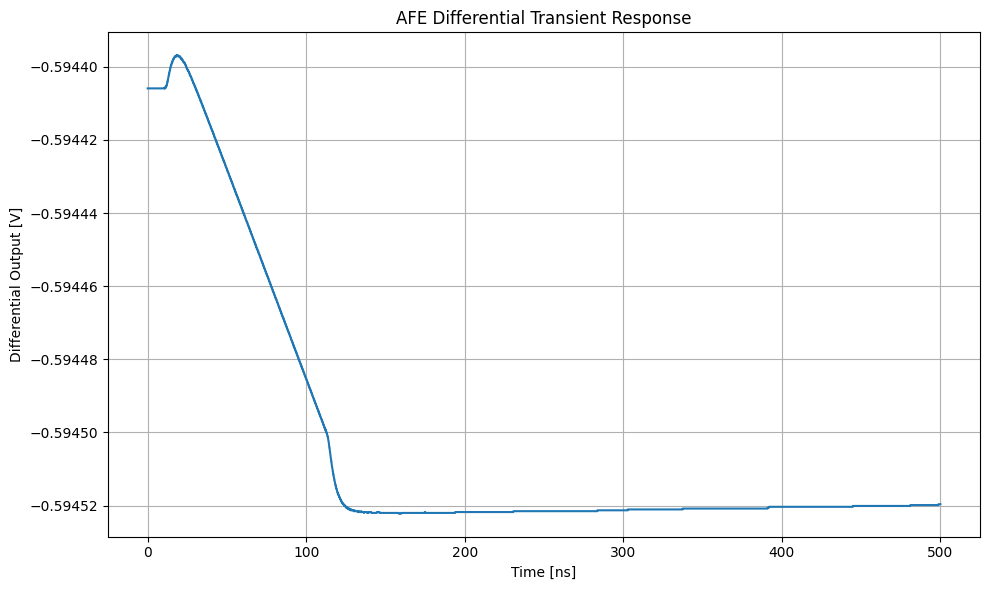


========== TRANSIENT REPORT ==========
Peak Value:              -0.594397 V
Final Settled Value:     -0.594520 V
Overshoot:               -0.02 percent
Settling Time (2%):      Not settled within simulation window
Ringing Crossings:       4



In [1]:
from PyLTSpice import RawRead
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# Configuration
# ============================================================
raw_path = "/workspace/Architecture/Analysis/CircuitModels/AFE/TestBenchTransientPulse.raw"
report_root = "./Reports"
os.makedirs(report_root, exist_ok=True)

# ============================================================
# Load RAW File
# ============================================================
raw = RawRead(raw_path)

time = np.real(raw.get_trace("time").get_wave(0))
vout_p = raw.get_trace("V(out_p)").get_wave(0)
vout_n = raw.get_trace("V(out_n)").get_wave(0)

vdiff = np.real(vout_p - vout_n)

# ============================================================
# Basic Metrics
# ============================================================

# Find steady-state peak (after rising edge)
peak_value = np.max(vdiff)

# Final settled value approximation (average of last 10 percent of waveform)
tail_start = int(len(vdiff) * 0.9)
final_value = np.mean(vdiff[tail_start:])

# Overshoot calculation
overshoot_percent = ((peak_value - final_value) / final_value) * 100

# ============================================================
# Settling Time (2 percent band)
# ============================================================

upper_bound = final_value * 1.02
lower_bound = final_value * 0.98

settling_index = None
for i in range(len(vdiff)):
    if np.all((vdiff[i:] <= upper_bound) & (vdiff[i:] >= lower_bound)):
        settling_index = i
        break

if settling_index is not None:
    settling_time = time[settling_index]
else:
    settling_time = None

# ============================================================
# Ringing Detection (simple peak counting after first peak)
# ============================================================

# Find peaks after main peak
main_peak_index = np.argmax(vdiff)
post_peak = vdiff[main_peak_index:]

zero_crossings = np.where(np.diff(np.sign(post_peak - final_value)))[0]
ring_count = len(zero_crossings)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(time * 1e9, vdiff)
plt.xlabel("Time [ns]")
plt.ylabel("Differential Output [V]")
plt.title("AFE Differential Transient Response")
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(report_root, "AFETransientResponse.svg"),
            format="svg")
plt.show()

# ============================================================
# Summary
# ============================================================

print("\n========== TRANSIENT REPORT ==========")
print(f"Peak Value:              {peak_value:.6f} V")
print(f"Final Settled Value:     {final_value:.6f} V")
print(f"Overshoot:               {overshoot_percent:.2f} percent")

if settling_time is not None:
    print(f"Settling Time (2%):      {settling_time*1e9:.2f} ns")
else:
    print("Settling Time (2%):      Not settled within simulation window")

print(f"Ringing Crossings:       {ring_count}")
print("======================================\n")

# ============================================================
# Simple Stability Flags
# ============================================================

if overshoot_percent > 15:
    print("WARNING: Overshoot greater than 15 percent")

if ring_count > 4:
    print("WARNING: Significant ringing detected")

if settling_time is None:
    print("WARNING: Output did not settle properly")